## 1. Introduction

- Phân tích tồn kho để giảm mất doanh thu do stockout và giảm chi phí do overstock

## 2. Import Libraries & Load Dataset

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Đường dẫn đến thư mục chứa dữ liệu
RAW_DIR = '../data/raw/'

# Thiết lập style cho biểu đồ
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

# Đọc dữ liệu
inventory = pd.read_csv(RAW_DIR + 'inventory.csv')
products = pd.read_csv(RAW_DIR + 'products.csv')
order_items = pd.read_csv(RAW_DIR + 'order_items.csv')
orders = pd.read_csv(RAW_DIR + 'orders.csv')    

print(f"Inventory shape: {inventory.shape}")
print(f"Products shape: {products.shape}")
print(f"Order items shape: {order_items.shape}")
print(f"Orders shape: {orders.shape}")

C:\Users\aokik\AppData\Local\Temp\ipykernel_8956\2125356324.py:13: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  order_items = pd.read_csv(RAW_DIR + 'order_items.csv')


Inventory shape: (60247, 17)
Products shape: (2412, 8)
Order items shape: (714669, 7)
Orders shape: (646945, 8)


## 3. Data Overview

In [3]:
inventory.head()

,snapshot_date,product_id,stock_on_hand,units_received,units_sold,stockout_days,days_of_supply,fill_rate,stockout_flag,overstock_flag,reorder_flag,sell_through_rate,product_name,category,segment,year,month
0,2022-10-31,1,3,1,1,2,90.0,0.9333,1,0,0,0.2500,DragonWear MA-01,Casual,All-weather,2022,10
1,2022-11-30,1,3,1,1,1,90.0,0.9667,1,0,0,0.2500,DragonWear MA-01,Casual,All-weather,2022,11
2,2022-12-31,1,3,1,1,1,90.0,0.9667,1,0,0,0.2500,DragonWear MA-01,Casual,All-weather,2022,12
3,2016-04-30,3,35,13,11,2,95.5,0.9333,1,1,0,0.2391,DragonWear MA-03,Casual,All-weather,2016,4
4,2016-05-31,3,36,11,10,1,108.0,0.9667,1,1,0,0.2174,DragonWear MA-03,Casual,All-weather,2016,5


In [4]:
inventory.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60247 entries, 0 to 60246
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   snapshot_date      60247 non-null  object 
 1   product_id         60247 non-null  int64  
 2   stock_on_hand      60247 non-null  int64  
 3   units_received     60247 non-null  int64  
 4   units_sold         60247 non-null  int64  
 5   stockout_days      60247 non-null  int64  
 6   days_of_supply     60247 non-null  float64
 7   fill_rate          60247 non-null  float64
 8   stockout_flag      60247 non-null  int64  
 9   overstock_flag     60247 non-null  int64  
 10  reorder_flag       60247 non-null  int64  
 11  sell_through_rate  60247 non-null  float64
 12  product_name       60247 non-null  object 
 13  category           60247 non-null  object 
 14  segment            60247 non-null  object 
 15  year               60247 non-null  int64  
 16  month              602

In [5]:
inventory.describe()

,product_id,stock_on_hand,units_received,units_sold,stockout_days,days_of_supply,fill_rate,stockout_flag,overstock_flag,reorder_flag,sell_through_rate,year,month
count,60247.000000,60247.000000,60247.000000,60247.000000,60247.000000,60247.000000,60247.000000,60247.000000,60247.000000,60247.0,60247.000000,60247.000000,60247.000000
mean,1311.408468,189.298455,18.046807,15.417764,1.160639,912.677576,0.961312,0.673411,0.762561,0.0,0.152275,2017.222799,6.617292
std,673.051769,316.976124,34.080228,28.404379,1.624490,2587.624108,0.054156,0.468969,0.425517,0.0,0.139291,2.972353,3.385629
min,1.000000,3.000000,1.000000,1.000000,0.000000,5.200000,0.066700,0.000000,0.000000,0.0,0.000400,2012.000000,1.000000
25%,760.000000,15.000000,2.000000,2.000000,0.000000,96.000000,0.933300,0.000000,1.000000,0.0,0.042100,2015.000000,4.000000
50%,1223.000000,62.000000,6.000000,6.000000,1.000000,240.000000,0.966700,1.000000,1.000000,0.0,0.111100,2017.000000,7.000000
75%,1942.000000,210.000000,19.000000,16.000000,2.000000,683.100000,1.000000,1.000000,1.000000,0.0,0.238100,2020.000000,10.000000
max,2412.000000,2673.000000,817.000000,670.000000,28.000000,68100.000000,1.000000,1.000000,1.000000,0.0,0.853100,2022.000000,12.000000


In [6]:
products.head()

,product_id,product_name,category,segment,size,color,price,cogs
0,536,SaigonFlex UC-01,Streetwear,Everyday,S,green,11059.650000,9704.842875
1,537,SaigonFlex UC-02,Streetwear,Everyday,M,silver,9523.076013,5393.870254
2,538,SaigonFlex UC-03,Streetwear,Everyday,L,pink,15951.633158,11371.919278
3,539,SaigonFlex UC-04,Streetwear,Everyday,XL,yellow,15753.717299,8573.172954
4,540,SaigonFlex UC-05,Streetwear,Everyday,S,red,15766.334536,14063.570406


In [7]:
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2412 entries, 0 to 2411
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   product_id    2412 non-null   int64  
 1   product_name  2412 non-null   object 
 2   category      2412 non-null   object 
 3   segment       2412 non-null   object 
 4   size          2412 non-null   object 
 5   color         2412 non-null   object 
 6   price         2412 non-null   float64
 7   cogs          2412 non-null   float64
dtypes: float64(2), int64(1), object(5)
memory usage: 150.9+ KB


In [8]:
products.describe()

,product_id,price,cogs
count,2412.000000,2412.000000,2412.000000
mean,1206.500000,4928.216231,3868.346732
std,696.428747,4776.737669,3878.584151
min,1.000000,9.056594,5.183829
25%,603.750000,59.444924,35.066367
50%,1206.500000,4399.605000,3184.934093
75%,1809.250000,7720.513784,5864.916462
max,2412.000000,40950.000000,38902.500000


In [9]:
order_items.head()

,order_id,product_id,quantity,unit_price,discount_amount,promo_id,promo_id_2
0,1,2400,7,1138.22,0.0,NaN,NaN
1,2,609,7,10166.25,0.0,NaN,NaN
2,3,396,3,11220.33,0.0,NaN,NaN
3,4,635,5,10639.25,0.0,NaN,NaN
4,6,1935,1,1597.84,0.0,NaN,NaN


In [10]:
order_items.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 714669 entries, 0 to 714668
Data columns (total 7 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   order_id         714669 non-null  int64  
 1   product_id       714669 non-null  int64  
 2   quantity         714669 non-null  int64  
 3   unit_price       714669 non-null  float64
 4   discount_amount  714669 non-null  float64
 5   promo_id         276316 non-null  object 
 6   promo_id_2       206 non-null     object 
dtypes: float64(2), int64(3), object(2)
memory usage: 38.2+ MB


In [11]:
order_items.describe()

,order_id,product_id,quantity,unit_price,discount_amount
count,714669.000000,714669.000000,714669.000000,714669.000000,714669.000000
mean,411615.076561,1234.931370,4.495988,5114.690157,1048.887415
std,240480.310686,691.332564,2.290143,3774.817912,2280.530606
min,1.000000,1.000000,1.000000,392.570000,0.000000
25%,203229.000000,689.000000,2.000000,1906.890000,0.000000
50%,409306.000000,990.000000,4.000000,4257.770000,0.000000
75%,618981.000000,2045.000000,6.000000,7273.760000,967.630000
max,834397.000000,2412.000000,8.000000,43056.000000,35235.470000


In [12]:
orders.head()

,order_id,order_date,customer_id,zip,order_status,payment_method,device_type,order_source
0,1,2012-07-04,58578,1109,delivered,credit_card,desktop,paid_search
1,2,2012-07-04,58621,1330,returned,cod,mobile,paid_search
2,3,2012-07-04,58811,1473,delivered,credit_card,desktop,direct
3,4,2012-07-04,59453,2360,delivered,credit_card,desktop,referral
4,6,2012-07-06,57821,2886,delivered,paypal,mobile,email_campaign


In [13]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 646945 entries, 0 to 646944
Data columns (total 8 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   order_id        646945 non-null  int64 
 1   order_date      646945 non-null  object
 2   customer_id     646945 non-null  int64 
 3   zip             646945 non-null  int64 
 4   order_status    646945 non-null  object
 5   payment_method  646945 non-null  object
 6   device_type     646945 non-null  object
 7   order_source    646945 non-null  object
dtypes: int64(3), object(5)
memory usage: 39.5+ MB


## 4. Data Cleaning

 ### 4.1 Clean Inventory

In [14]:
print(f"Số dòng trước khi clean: {len(inventory):,}")


# Chuyển đổi kiểu dữ liệu
inventory['snapshot_date'] = pd.to_datetime(inventory['snapshot_date'], errors='coerce')

# Kiểm tra missing values
missing_inv = inventory.isnull().sum()
if missing_inv.sum() > 0:
    print(f"Missing values:")
    print(missing_inv[missing_inv > 0])
else:
    print(f"Không có missing values")

# Xử lý stock_on_hand âm (lỗi logic)
neg_stock = (inventory['stock_on_hand'] < 0).sum()
if neg_stock > 0:
    inventory.loc[inventory['stock_on_hand'] < 0, 'stock_on_hand'] = 0
    print(f"Đã sửa {neg_stock} dòng có stock_on_hand < 0 thành 0")

# Xử lý sell_through_rate ngoài [0,100]
invalid_str = ((inventory['sell_through_rate'] > 100) | (inventory['sell_through_rate'] < 0)).sum()
if invalid_str > 0:
    inventory.loc[inventory['sell_through_rate'] > 100, 'sell_through_rate'] = 100
    inventory.loc[inventory['sell_through_rate'] < 0, 'sell_through_rate'] = 0
    print(f"Đã sửa {invalid_str} dòng có sell_through_rate ngoài [0,100]")

# Xử lý stockout_days > 31 (không thể có trong 1 tháng)
invalid_days = (inventory['stockout_days'] > 31).sum()
if invalid_days > 0:
    inventory.loc[inventory['stockout_days'] > 31, 'stockout_days'] = 31
    print(f"Đã sửa {invalid_days} dòng có stockout_days > 31")

# Xử lý days_of_supply (NaN hoặc vô cùng)
inventory['days_of_supply'] = pd.to_numeric(inventory['days_of_supply'], errors='coerce')
inventory.loc[inventory['days_of_supply'] > 365, 'days_of_supply'] = 365
inventory.loc[inventory['days_of_supply'] < 0, 'days_of_supply'] = 0
days_nan = inventory['days_of_supply'].isna().sum()
if days_nan > 0:
    inventory['days_of_supply'].fillna(inventory['days_of_supply'].median(), inplace=True)
    print(f"Đã điền {days_nan} giá trị days_of_supply bằng median")

# Xóa duplicate (product_id + snapshot_date)
before_dedup = len(inventory)
inventory = inventory.drop_duplicates(subset=['product_id', 'snapshot_date'], keep='last')
after_dedup = len(inventory)
if before_dedup > after_dedup:
    print(f"Đã xóa {before_dedup - after_dedup} dòng duplicate")

print(f"Số dòng sau khi clean: {len(inventory):,}")

Số dòng trước khi clean: 60,247
Không có missing values
Số dòng sau khi clean: 60,247


### 4.2 Clean Products

In [15]:
print(f"Số dòng trước khi clean: {len(products):,}")

# Xử lý missing values trong categorical columns
cat_cols = ['category', 'segment', 'size', 'color']
for col in cat_cols:
    if products[col].isna().sum() > 0:
        products[col].fillna('Unknown', inplace=True)
        print(f"Đã điền 'Unknown' cho {col}")

# Xử lý price âm hoặc bằng 0
neg_price = (products['price'] <= 0).sum()
if neg_price > 0:
    products.loc[products['price'] <= 0, 'price'] = products['price'].median()
    print(f"Đã sửa {neg_price} dòng có price <= 0")

# Kiểm tra ràng buộc cogs < price
invalid_cogs = (products['cogs'] >= products['price']).sum()
if invalid_cogs > 0:
    products.loc[products['cogs'] >= products['price'], 'cogs'] = products['price'] * 0.7
    print(f"Đã sửa {invalid_cogs} dòng có cogs >= price (set = 70% price)")

# Xóa duplicate product_id
products = products.drop_duplicates(subset=['product_id'], keep='first')

print(f"Số dòng sau khi clean: {len(products):,}")

Số dòng trước khi clean: 2,412
Số dòng sau khi clean: 2,412


 ### 4.3 Clean Orders

In [16]:
print(f"Số dòng trước khi clean: {len(orders):,}")

# Chuyển đổi kiểu dữ liệu
orders["order_date"] = pd.to_datetime(orders["order_date"])

# Xử lý missing values
missing_orders = orders.isnull().sum()
if missing_orders.sum() > 0:
    print(f"Missing values:")
    print(missing_orders[missing_orders > 0])
else:    
    print(f"Không có missing values")

# Xử lý duplicate order_id
orders = orders.drop_duplicates(subset=['order_id'], keep='first')

print(f"Số dòng sau khi clean: {len(orders):,}")

Số dòng trước khi clean: 646,945
Không có missing values
Số dòng sau khi clean: 646,945


### 4.4 Clean Order_Items

In [17]:
print(f"Số dòng trước khi clean: {len(order_items):,}")

# Xử lý missing values trong các cột promo_id 
pro_cols = ['promo_id', 'promo_id_2']
for col in pro_cols:
    if order_items[col].isnull().sum():
        order_items.fillna({col: "None"}, inplace=True)
        print(f"Đã điền None cho {col}")

# Xử lý quantity <= 0
neg_qty = (order_items['quantity'] <= 0).sum()
if neg_qty > 0:
    order_items.loc[order_items['quantity'] <= 0, 'quantity'] = 1
    print(f"Đã sửa {neg_qty} dòng có quantity <= 0 thành 1")

# Xử lý price <= 0
neg_price = (order_items['unit_price'] <= 0).sum()
if neg_price > 0:
    order_items.loc[order_items['unit_price'] <= 0, 'unit_price'] = order_items['unit_price'].median()
    print(f"Đã sửa {neg_price} dòng có unit_price <= 0")

# discount_amount không được vượt quá tổng giá trị đơn hàng
order_items['total_value'] = order_items['quantity'] * order_items['unit_price']
invalid_discount = (order_items['discount_amount'] > order_items['total_value']).sum()
if invalid_discount > 0:
    order_items.loc[order_items['discount_amount'] > order_items['total_value'], 'discount_amount'] = order_items['total_value'] * 0.3
    print(f"Đã điều chỉnh {invalid_discount} dòng có discount_amount > total_value")

# Xóa duplicate (order_id + product_id)
before_dedup = len(order_items)
order_items = order_items.drop_duplicates(subset=['order_id', 'product_id'], keep='last')
after_dedup = len(order_items)
if before_dedup > after_dedup:
    print(f"Đã xóa {before_dedup - after_dedup} dòng duplicate")


print (f"Số dòng sau khi clean: {len(order_items):,}")



Số dòng trước khi clean: 714,669
Đã điền None cho promo_id
Đã điền None cho promo_id_2
Đã xóa 16 dòng duplicate
Số dòng sau khi clean: 714,653


### 4.4 Create Auxiliary Columns For Analysis

In [18]:
# Thêm tháng, năm, quý cho inventory
inventory['snapshot_date'] = pd.to_datetime(inventory['snapshot_date'])
inventory['year'] = inventory['snapshot_date'].dt.year
inventory['month'] = inventory['snapshot_date'].dt.month
inventory['quarter'] = inventory['snapshot_date'].dt.quarter

# Tính net_revenue, discount_rate và is_stackable cho order_items
order_items['net_revenue'] = order_items['total_value'] - order_items['discount_amount']
order_items['discount_rate'] = (order_items['discount_amount'] / order_items['total_value'] * 100).round(2)
order_items.fillna({'discount_rate': 0}, inplace=True)  
order_items['is_stackable'] = ((order_items['promo_id'] != 'None') & 
                                      (order_items['promo_id_2'] != 'None')).astype(int)



## 5. Merge Data & Feature Engineering

### 5.1 Merge inventory với products

In [19]:
inventory_full = inventory.merge(products[['product_id', 'category', 'segment', 'product_name', 'price', 'cogs']], 
                                  on='product_id', how='left')
print(f"Số dòng sau merge: {len(inventory_full):,}")
print(f"Số cột sau merge: {len(inventory_full.columns)}")

# Xử lý category sau merge (có thể có 2 cột category_x, category_y do trùng tên)
inventory_full["category"] = inventory_full["category_y"].fillna(inventory_full["category_x"])
inventory_full.drop(columns=["category_x", "category_y"], inplace=True)

# Xử lý product_name sau merge
inventory_full["product_name"] = inventory_full["product_name_y"].fillna(inventory_full["product_name_x"])
inventory_full.drop(columns=["product_name_x", "product_name_y"], inplace=True)

# Xử lý segment sau merge
inventory_full["segment"] = inventory_full["segment_y"].fillna(inventory_full["segment_x"])
inventory_full.drop(columns=["segment_x", "segment_y"], inplace=True)

inventory_full.head()


Số dòng sau merge: 60,247
Số cột sau merge: 23


,snapshot_date,product_id,stock_on_hand,units_received,units_sold,stockout_days,days_of_supply,fill_rate,stockout_flag,overstock_flag,reorder_flag,sell_through_rate,year,month,quarter,price,cogs,category,product_name,segment
0,2022-10-31,1,3,1,1,2,90.0,0.9333,1,0,0,0.2500,2022,10,4,4945.500000,2732.883300,Casual,DragonWear MA-01,All-weather
1,2022-11-30,1,3,1,1,1,90.0,0.9667,1,0,0,0.2500,2022,11,4,4945.500000,2732.883300,Casual,DragonWear MA-01,All-weather
2,2022-12-31,1,3,1,1,1,90.0,0.9667,1,0,0,0.2500,2022,12,4,4945.500000,2732.883300,Casual,DragonWear MA-01,All-weather
3,2016-04-30,3,35,13,11,2,95.5,0.9333,1,1,0,0.2391,2016,4,2,10831.377188,10289.808329,Casual,DragonWear MA-03,All-weather
4,2016-05-31,3,36,11,10,1,108.0,0.9667,1,1,0,0.2174,2016,5,2,10831.377188,10289.808329,Casual,DragonWear MA-03,All-weather


In [20]:
# Kiểm tra missing values sau merge
missing_cat = inventory_full['category'].isna().sum()
if missing_cat > 0:
    print(f"Có {missing_cat} dòng không có category (gán = 'Unknown')")
    inventory_full['category'].fillna('Unknown', inplace=True)

### 5.2. Merge orders với order_items & Create demand

In [21]:
orders_items_full = order_items.merge(orders[["order_id", "order_date"]],
    on="order_id", how="left")
print(f"Số dòng sau merge: {len(orders_items_full):,}")
print(f"Số cột sau merge: {len(orders_items_full.columns)}")

orders_items_full.head()

Số dòng sau merge: 714,653
Số cột sau merge: 12


,order_id,product_id,quantity,unit_price,discount_amount,promo_id,promo_id_2,total_value,net_revenue,discount_rate,is_stackable,order_date
0,1,2400,7,1138.22,0.0,None,None,7967.54,7967.54,0.0,0,2012-07-04
1,2,609,7,10166.25,0.0,None,None,71163.75,71163.75,0.0,0,2012-07-04
2,3,396,3,11220.33,0.0,None,None,33660.99,33660.99,0.0,0,2012-07-04
3,4,635,5,10639.25,0.0,None,None,53196.25,53196.25,0.0,0,2012-07-04
4,6,1935,1,1597.84,0.0,None,None,1597.84,1597.84,0.0,0,2012-07-06


In [22]:
# Kiểm tra missing values sau merge
missing_order = orders_items_full['order_date'].isna().sum()
if missing_order > 0:
    print(f"{missing_order} dòng có order_id không tồn tại trong orders.csv")
    orders_items_full = orders_items_full.dropna(subset=['order_date'])
    print(f"Đã xóa {missing_order} dòng")


In [23]:
# Thêm cột tháng cho orders_items_full
orders_items_full["month"] = orders_items_full["order_date"].dt.month

# Tạo demand theo product_id và tháng
demand = orders_items_full.groupby(
    ["product_id", "month"]
)["quantity"].sum().reset_index()

demand.head()

,product_id,month,quantity
0,1,12,8
1,3,1,157
2,3,2,169
3,3,3,244
4,3,4,285


### 5.3. Create New Features For Analysis 

In [24]:
# Phân loại mức độ rủi ro stockout dựa trên days_of_supply
def get_stockout_risk(day_supply):
    if day_supply < 7:
        return 'CRITICAL'
    elif day_supply < 15:
        return 'HIGH'
    elif day_supply < 30:
        return 'MEDIUM'
    else:
        return 'LOW'

inventory_full['stockout_risk'] = inventory_full['days_of_supply'].apply(get_stockout_risk)

# Phân loại mức độ overstock
def get_overstock_level(overstock_flag, days_supply):
    if overstock_flag == 1:
        if days_supply > 90:
            return 'SEVERE'
        elif days_supply > 60:
            return 'MODERATE'
        else:
            return 'MILD'
    return 'NONE'

inventory_full['overstock_level'] = inventory_full.apply(
    lambda x: get_overstock_level(x['overstock_flag'], x['days_of_supply']), axis=1
)

# Tính gross margin
inventory_full['gross_margin'] = (inventory_full['price'] - inventory_full['cogs']) / inventory_full['price'] * 100

# Giả định: Mỗi ngày stockout mất 30% doanh thu bình thường
inventory_full['daily_avg_sales_units'] = inventory_full['units_sold'] / 30  # 30 ngày/tháng
inventory_full['daily_revenue_normal'] = inventory_full['daily_avg_sales_units'] * inventory_full['price']
inventory_full['potential_loss_stockout'] = (
    inventory_full['stockout_days'] * 
    inventory_full['daily_revenue_normal'] * 
    0.3  # Hệ số thiệt hại (30%)
)

print("\n Thống kê nhanh:")
print(f"- Số sản phẩm duy nhất: {inventory_full['product_id'].nunique():,}")
print(f"- Số danh mục: {inventory_full['category'].nunique()}")
print(f"- Thời gian: {inventory_full['snapshot_date'].min().date()} → {inventory_full['snapshot_date'].max().date()}")

inventory_full.head()


 Thống kê nhanh:
- Số sản phẩm duy nhất: 1,624
- Số danh mục: 4
- Thời gian: 2012-07-31 → 2022-12-31


,snapshot_date,product_id,stock_on_hand,units_received,units_sold,stockout_days,days_of_supply,fill_rate,stockout_flag,overstock_flag,...,cogs,category,product_name,segment,stockout_risk,overstock_level,gross_margin,daily_avg_sales_units,daily_revenue_normal,potential_loss_stockout
0,2022-10-31,1,3,1,1,2,90.0,0.9333,1,0,...,2732.883300,Casual,DragonWear MA-01,All-weather,LOW,NONE,44.74,0.033333,164.850000,98.910000
1,2022-11-30,1,3,1,1,1,90.0,0.9667,1,0,...,2732.883300,Casual,DragonWear MA-01,All-weather,LOW,NONE,44.74,0.033333,164.850000,49.455000
2,2022-12-31,1,3,1,1,1,90.0,0.9667,1,0,...,2732.883300,Casual,DragonWear MA-01,All-weather,LOW,NONE,44.74,0.033333,164.850000,49.455000
3,2016-04-30,3,35,13,11,2,95.5,0.9333,1,1,...,10289.808329,Casual,DragonWear MA-03,All-weather,LOW,SEVERE,5.00,0.366667,3971.504969,2382.902981
4,2016-05-31,3,36,11,10,1,108.0,0.9667,1,1,...,10289.808329,Casual,DragonWear MA-03,All-weather,LOW,SEVERE,5.00,0.333333,3610.459063,1083.137719


### 5.4. Merge inventory_full với demand

In [25]:
final_df = inventory_full.merge(demand, on=["product_id", "month"],how="left")

# Kiểm tra missing values sau merge
missing_demand = final_df['quantity'].isna().sum()
if missing_demand > 0:
    print(f"{missing_demand} dòng có quantity là NaN (gán = 0)")
    final_df.fillna({'quantity': 0}, inplace=True)

# Đổi tên cột quantity thành demand để dễ hiểu
final_df.rename(columns={'quantity': 'demand'}, inplace=True)

final_df.head()

540 dòng có quantity là NaN (gán = 0)


,snapshot_date,product_id,stock_on_hand,units_received,units_sold,stockout_days,days_of_supply,fill_rate,stockout_flag,overstock_flag,...,category,product_name,segment,stockout_risk,overstock_level,gross_margin,daily_avg_sales_units,daily_revenue_normal,potential_loss_stockout,demand
0,2022-10-31,1,3,1,1,2,90.0,0.9333,1,0,...,Casual,DragonWear MA-01,All-weather,LOW,NONE,44.74,0.033333,164.850000,98.910000,0.0
1,2022-11-30,1,3,1,1,1,90.0,0.9667,1,0,...,Casual,DragonWear MA-01,All-weather,LOW,NONE,44.74,0.033333,164.850000,49.455000,0.0
2,2022-12-31,1,3,1,1,1,90.0,0.9667,1,0,...,Casual,DragonWear MA-01,All-weather,LOW,NONE,44.74,0.033333,164.850000,49.455000,8.0
3,2016-04-30,3,35,13,11,2,95.5,0.9333,1,1,...,Casual,DragonWear MA-03,All-weather,LOW,SEVERE,5.00,0.366667,3971.504969,2382.902981,285.0
4,2016-05-31,3,36,11,10,1,108.0,0.9667,1,1,...,Casual,DragonWear MA-03,All-weather,LOW,SEVERE,5.00,0.333333,3610.459063,1083.137719,272.0


## 6. Exploratory Data Analysis (EDA)

### 6.1 Stockout

#### Xu hướng stockout theo thời gian

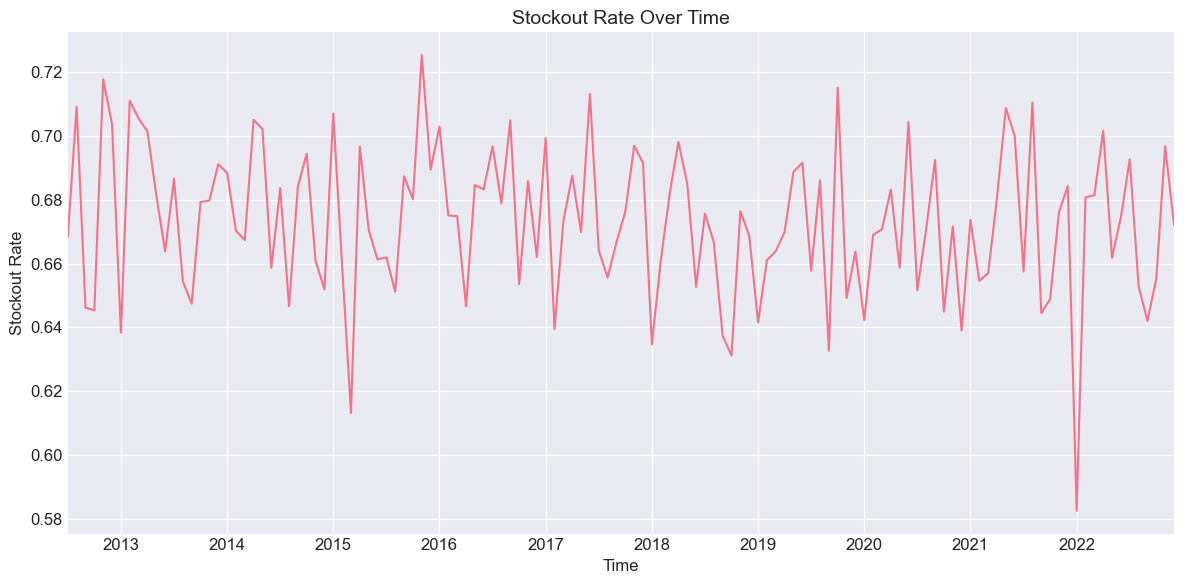

In [26]:
stockout_time = final_df.groupby("snapshot_date")["stockout_flag"].mean()

plt.figure()
stockout_time.plot()

plt.title("Stockout Rate Over Time", fontsize=14)
plt.xlabel("Time")
plt.ylabel("Stockout Rate")

plt.grid(True)
plt.tight_layout()
plt.show()

#### Stockout theo category

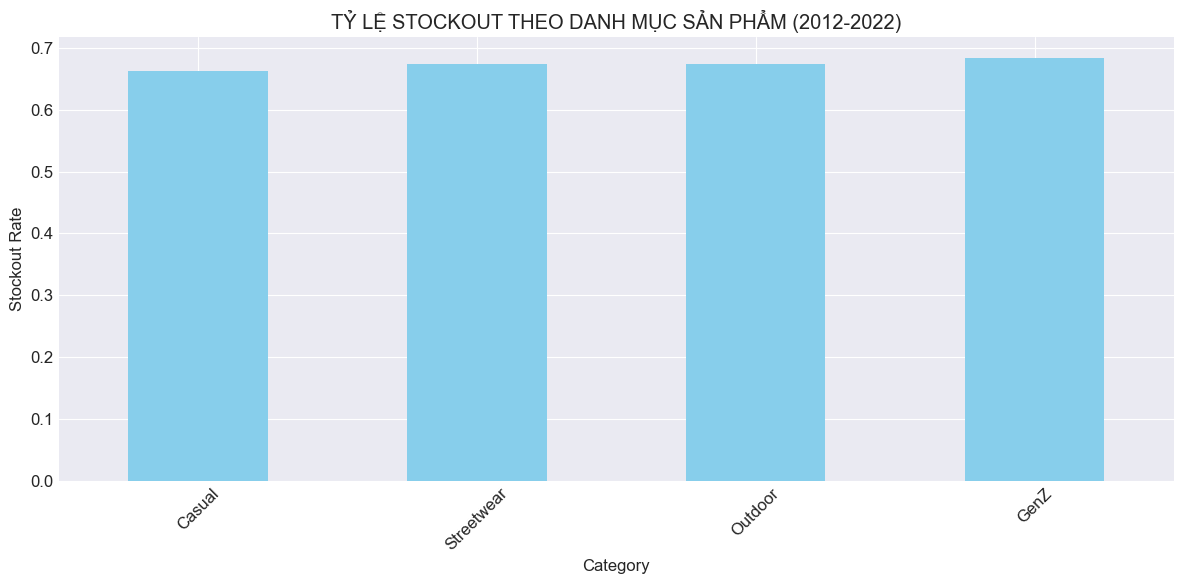

In [27]:
cat_stockout = final_df.groupby("category")["stockout_flag"].mean().sort_values()

plt.figure()
cat_stockout.plot(kind="bar", color="skyblue")

plt.title("TỶ LỆ STOCKOUT THEO DANH MỤC SẢN PHẨM (2012-2022)")
plt.xlabel("Category")
plt.ylabel("Stockout Rate")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### Heatmap Stockout

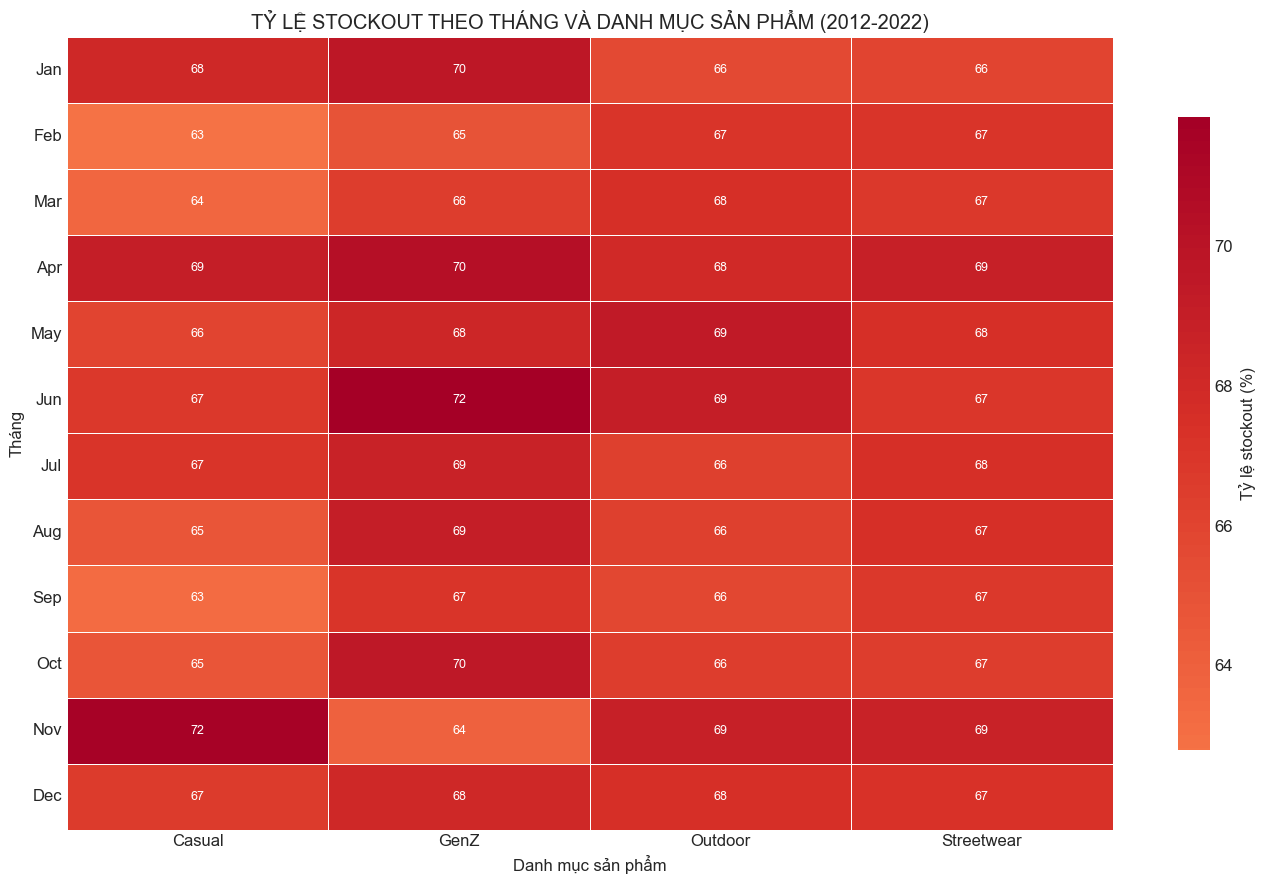


PHÂN TÍCH SỐ LIỆU:

Danh mục stockout cao nhất: GenZ (68.2%)
Danh mục stockout thấp nhất: Casual (66.2%)

Tháng stockout cao nhất: Apr (69.1%)
Tháng stockout thấp nhất: Feb (65.5%)

Thiệt hại ước tính do stockout (2012-2022): 77,205,499


In [28]:
# Tính tỷ lệ stockout
stockout_pivot = inventory_full.groupby(['month', 'category'])['stockout_flag'].mean() * 100
stockout_pivot = stockout_pivot.unstack()

fig, ax = plt.subplots(figsize=(14, 9))

# Tạo heatmap với annotation
heatmap = sns.heatmap(stockout_pivot, 
                      annot=True, 
                      fmt='.0f',
                      cmap='RdYlGn_r',
                      center=50,
                      cbar_kws={'label': 'Tỷ lệ stockout (%)', 'shrink': 0.8},
                      linewidths=0.5,
                      ax=ax,
                      annot_kws={'fontsize': 9})


ax.set_title('TỶ LỆ STOCKOUT THEO THÁNG VÀ DANH MỤC SẢN PHẨM (2012-2022)')
ax.set_xlabel('Danh mục sản phẩm')
ax.set_ylabel('Tháng')

month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
ax.set_yticklabels(month_names, rotation=0)

plt.tight_layout()
plt.show()

# Phân tích số liệu cụ thể
print("\nPHÂN TÍCH SỐ LIỆU:")

cat_mean = stockout_pivot.mean().sort_values(ascending=False)
print(f"\nDanh mục stockout cao nhất: {cat_mean.index[0]} ({cat_mean.iloc[0]:.1f}%)")
print(f"Danh mục stockout thấp nhất: {cat_mean.index[-1]} ({cat_mean.iloc[-1]:.1f}%)")

month_mean = stockout_pivot.mean(axis=1).sort_values(ascending=False)
print(f"\nTháng stockout cao nhất: {month_names[month_mean.index[0]-1]} ({month_mean.iloc[0]:.1f}%)")
print(f"Tháng stockout thấp nhất: {month_names[month_mean.index[-1]-1]} ({month_mean.iloc[-1]:.1f}%)")

total_loss = inventory_full['potential_loss_stockout'].sum()
print(f"\nThiệt hại ước tính do stockout (2012-2022): {total_loss:,.0f}")

### 6.2 Overstock

#### Overstock theo category

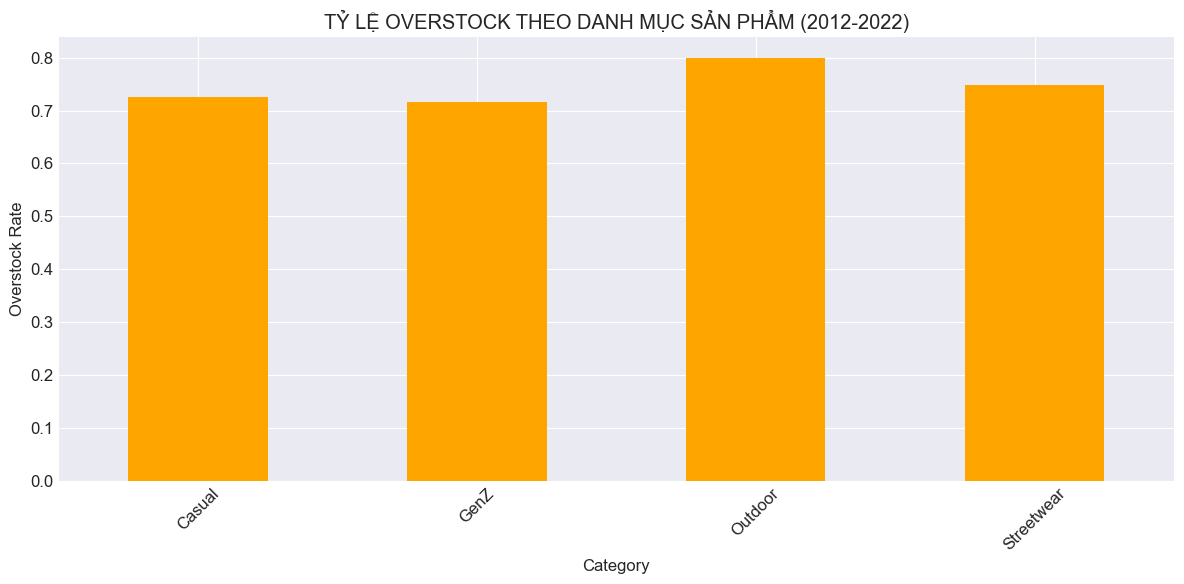

In [29]:
cat_overstock = final_df.groupby("category")["overstock_flag"].mean()

plt.figure()
cat_overstock.plot(kind="bar", color="orange")

plt.title("TỶ LỆ OVERSTOCK THEO DANH MỤC SẢN PHẨM (2012-2022)")
plt.xlabel("Category")
plt.ylabel("Overstock Rate")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 6.3. Trade off Overstock vs Stockout

#### Scatter stockout vs overstock

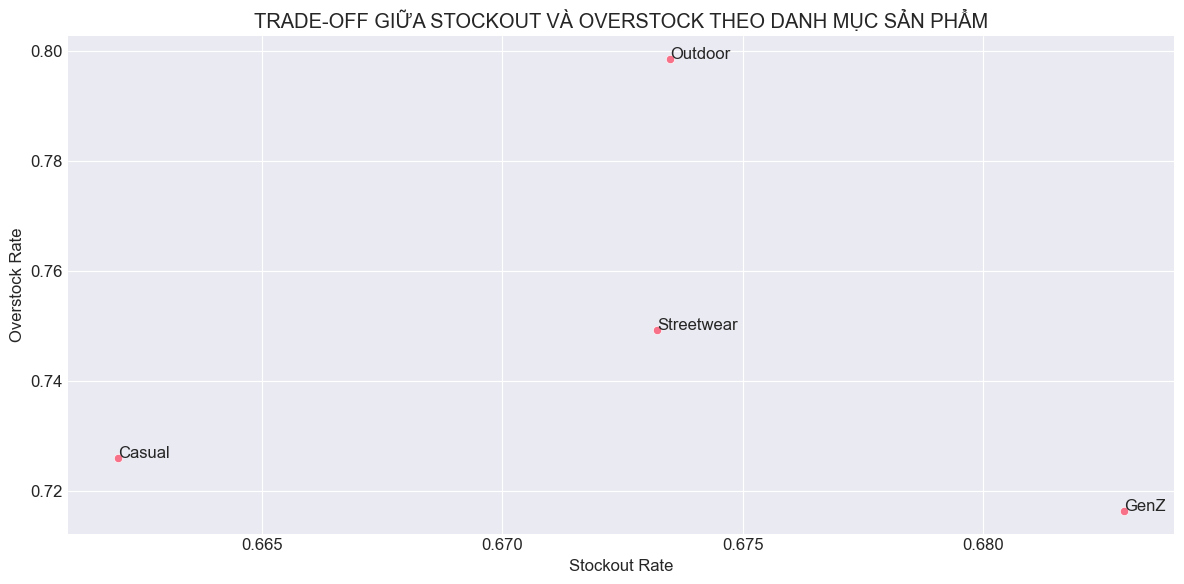

In [30]:
# Vẽ biểu đồ scatter stockout vs overstock theo category
group = final_df.groupby("category").agg({
    "stockout_flag": "mean",
    "overstock_flag": "mean"
}).reset_index()

plt.figure()
sns.scatterplot(data=group, x="stockout_flag", y="overstock_flag")

# annotate từng điểm
for i in range(len(group)):
    plt.text(group["stockout_flag"][i],
             group["overstock_flag"][i],
             group["category"][i])

plt.title("TRADE-OFF GIỮA STOCKOUT VÀ OVERSTOCK THEO DANH MỤC SẢN PHẨM")
plt.xlabel("Stockout Rate")
plt.ylabel("Overstock Rate")

plt.tight_layout()
plt.show()

#### Stockout vs Overstock Paradox

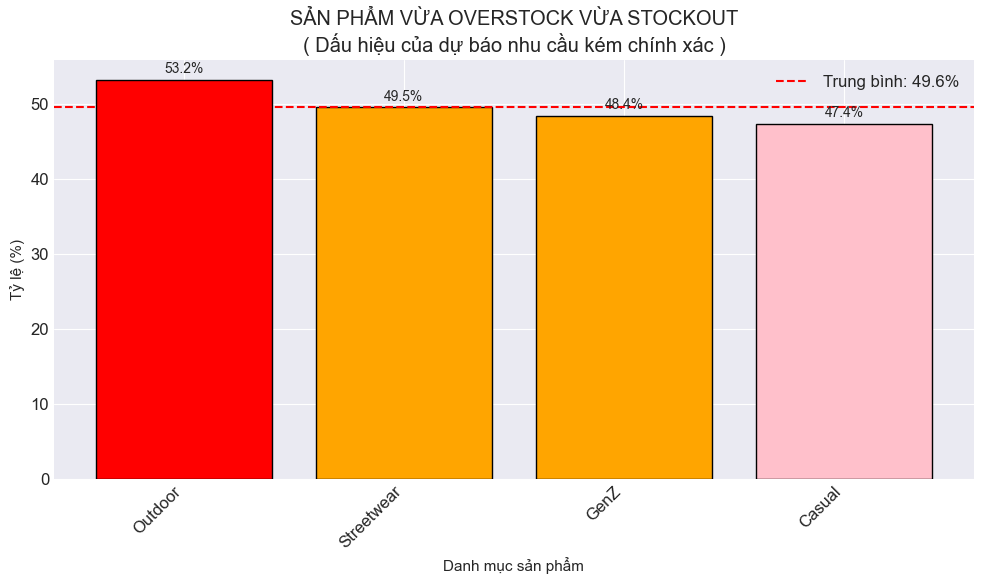

PHÂN TÍCH

1. Mô tả:
Biểu đồ cho thấy tỷ lệ sản phẩm trong mỗi danh mục vừa bị overstock (thừa hàng) 
vừa bị stockout (hết hàng) trong cùng một tháng hoặc các tháng khác nhau.

2. Key insights:
• Trung bình toàn doanh nghiệp: 49.6% số tháng có nghịch lý
• Danh mục tệ nhất: Outdoor (53.2%)
• Đây là dấu hiệu cho thấy hệ thống dự báo nhu cầu đang hoạt động kém hiệu quả

3. Ý nghĩa kinh doanh:
Doanh nghiệp vừa nhập quá nhiều hàng (overstock) lại vừa để hết hàng (stockout) 
của cùng một sản phẩm → Lãng phí nguồn lực và mất doanh thu.



In [31]:
# Tạo cột paradox
inventory_full['paradox'] = ((inventory_full['overstock_flag'] == 1) & 
                             (inventory_full['stockout_flag'] == 1))

# Tính tỷ lệ paradox theo danh mục
paradox_by_cat = inventory_full.groupby('category')['paradox'].mean() * 100
paradox_by_cat = paradox_by_cat.sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))

# Vẽ bar chart
colors = ['red' if i == 0 else 'orange' if i < 3 else 'pink' for i in range(len(paradox_by_cat))]
bars = ax.bar(range(len(paradox_by_cat)), paradox_by_cat.values, color=colors, edgecolor='black')

ax.set_xticks(range(len(paradox_by_cat)))
ax.set_xticklabels(paradox_by_cat.index, rotation=45, ha='right')
ax.set_ylabel('Tỷ lệ (%)', fontsize=11)
ax.set_xlabel('Danh mục sản phẩm', fontsize=11)
ax.set_title('SẢN PHẨM VỪA OVERSTOCK VỪA STOCKOUT\n( Dấu hiệu của dự báo nhu cầu kém chính xác )')

# Thêm đường trung bình
avg_line = paradox_by_cat.mean()
ax.axhline(y=avg_line, color='red', linestyle='--', linewidth=1.5, 
           label=f'Trung bình: {avg_line:.1f}%')
ax.legend()

# Thêm số liệu trên cột
for bar, val in zip(bars, paradox_by_cat.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

print("PHÂN TÍCH")

print(f"""
1. Mô tả:
Biểu đồ cho thấy tỷ lệ sản phẩm trong mỗi danh mục vừa bị overstock (thừa hàng) 
vừa bị stockout (hết hàng) trong cùng một tháng hoặc các tháng khác nhau.

2. Key insights:
• Trung bình toàn doanh nghiệp: {avg_line:.1f}% số tháng có nghịch lý
• Danh mục tệ nhất: {paradox_by_cat.index[0]} ({paradox_by_cat.iloc[0]:.1f}%)
• Đây là dấu hiệu cho thấy hệ thống dự báo nhu cầu đang hoạt động kém hiệu quả

3. Ý nghĩa kinh doanh:
Doanh nghiệp vừa nhập quá nhiều hàng (overstock) lại vừa để hết hàng (stockout) 
của cùng một sản phẩm → Lãng phí nguồn lực và mất doanh thu.
""")

### 6.3. Predictive Stockout Seasonal Cycle

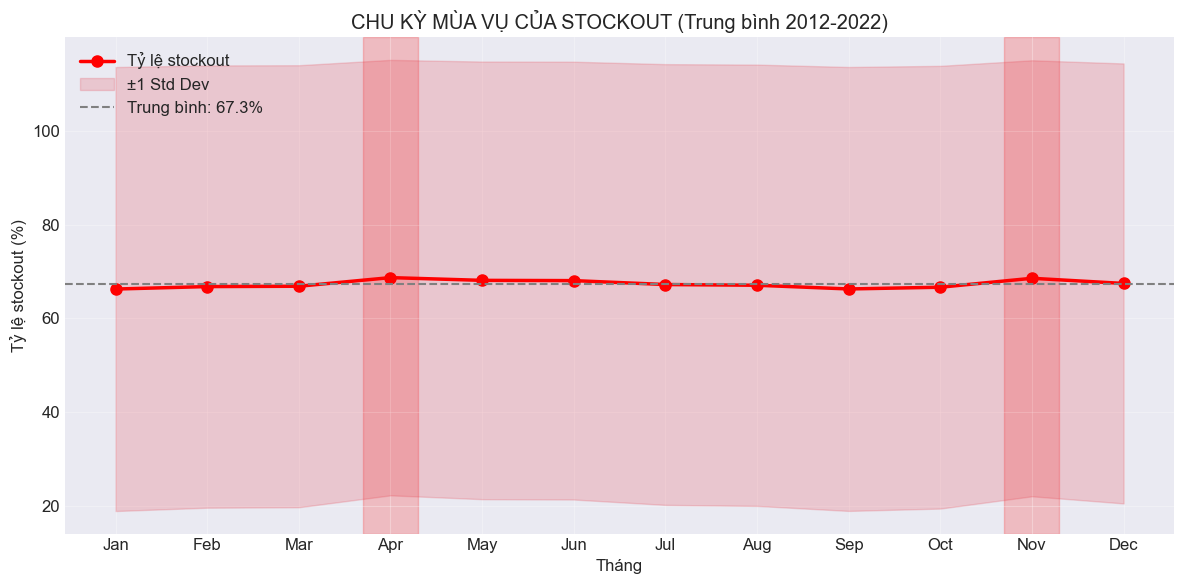

PHÂN TÍCH
 
1. Mô tả:
Biểu đồ thể hiện tỷ lệ stockout trung bình theo từng tháng trong năm, 
dựa trên dữ liệu 10 năm (2012-2022).

2. Key insights:
- Stockout cao nhất vào tháng  4(68.7%) và tháng 11 (68.6%)
- Stockout thấp nhất vào tháng 1-3, 8-10
- Chênh lệch giữa tháng cao nhất và thấp nhất: 2.4%

3. Dự báo cho năm 2023:
- Dự kiến tháng 4/2023: ~68.7% stockout (±46.4%)
- Dự kiến tháng 11/2023: ~68.6% stockout (±46.4%)

4. Đề xuất hành động:
- Tăng lượng nhập kho từ đầu tháng 3 và đầu tháng 10
- Chuẩn bị kế hoạch dự phòng cho mùa cao điểm



In [32]:
# Tính stockout rate trung bình theo tháng
monthly_stockout = inventory_full.groupby('month')['stockout_flag'].mean() * 100
monthly_std = inventory_full.groupby('month')['stockout_flag'].std() * 100

fig, ax = plt.subplots(figsize=(12, 6))

# Vẽ line chart
months = range(1, 13)
ax.plot(months, monthly_stockout.values, 'o-', linewidth=2.5, markersize=8, 
        color='red', label='Tỷ lệ stockout')

# Thêm vùng biến động (standard deviation)
ax.fill_between(months, 
                monthly_stockout.values - monthly_std.values,
                monthly_stockout.values + monthly_std.values,
                alpha=0.2, color='#e63946', label='±1 Std Dev')

# Đánh dấu các tháng cao điểm
peak_months = [4, 11]
for month in peak_months:
    ax.axvspan(month - 0.3, month + 0.3, alpha=0.2, color='red', zorder=0)

ax.set_xticks(months)
ax.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                    'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
ax.set_xlabel('Tháng')
ax.set_ylabel('Tỷ lệ stockout (%)')
ax.set_title('CHU KỲ MÙA VỤ CỦA STOCKOUT (Trung bình 2012-2022)')

# Đường trung bình
avg_line = monthly_stockout.mean()
ax.axhline(y=avg_line, color='gray', linestyle='--', 
           label=f'Trung bình: {avg_line:.1f}%')


ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


print("PHÂN TÍCH")

print(f""" 
1. Mô tả:
Biểu đồ thể hiện tỷ lệ stockout trung bình theo từng tháng trong năm, 
dựa trên dữ liệu 10 năm (2012-2022).

2. Key insights:
- Stockout cao nhất vào tháng  4({monthly_stockout.loc[4]:.1f}%) và tháng 11 ({monthly_stockout.loc[11]:.1f}%)
- Stockout thấp nhất vào tháng 1-3, 8-10
- Chênh lệch giữa tháng cao nhất và thấp nhất: {monthly_stockout.max() - monthly_stockout.min():.1f}%

3. Dự báo cho năm 2023:
- Dự kiến tháng 4/2023: ~{monthly_stockout.loc[4]:.1f}% stockout (±{monthly_std.loc[4]:.1f}%)
- Dự kiến tháng 11/2023: ~{monthly_stockout.loc[11]:.1f}% stockout (±{monthly_std.loc[11]:.1f}%)

4. Đề xuất hành động:
- Tăng lượng nhập kho từ đầu tháng 3 và đầu tháng 10
- Chuẩn bị kế hoạch dự phòng cho mùa cao điểm
""")

### 6.4. Demand vs Stock

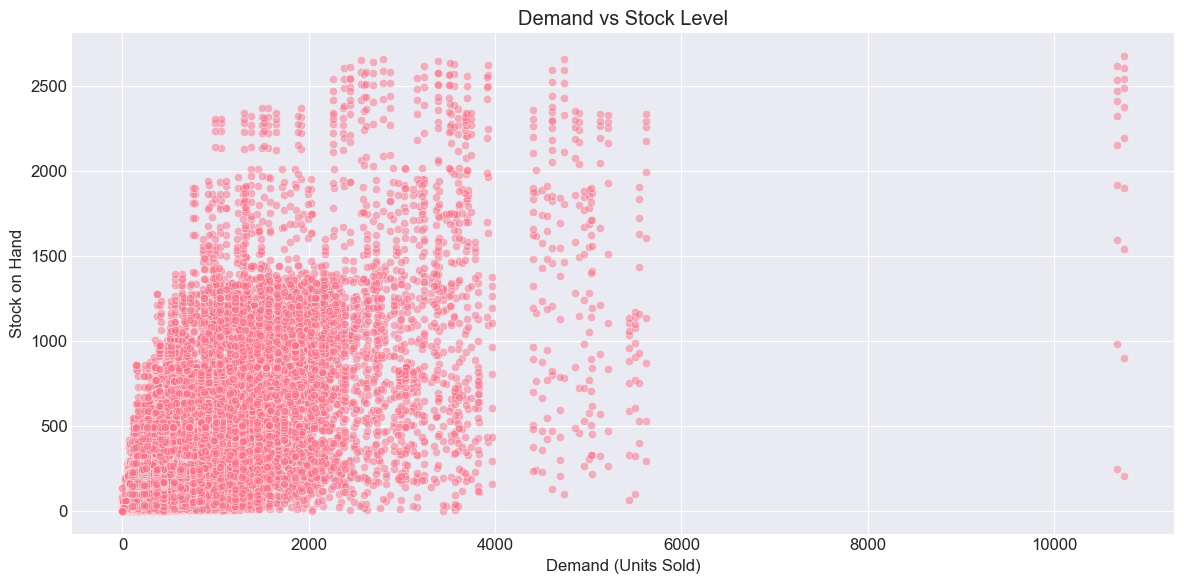

In [33]:
plt.figure()
sns.scatterplot(data=final_df, x="demand", y="stock_on_hand", alpha=0.5)

plt.title("Demand vs Stock Level")
plt.xlabel("Demand (Units Sold)")
plt.ylabel("Stock on Hand")

plt.tight_layout()
plt.show()

In [34]:
# 1. Phân bố dữ liệu:

# Chia demand thành 3 nhóm
final_df['demand_group'] = pd.cut(final_df['demand'], 
                                   bins=[-1, 1000, 5000, 100000],
                                   labels=['Thấp (<1000)', 'Trung bình (1000-5000)', 'Cao (>5000)'])

# Chia stock thành 3 nhóm
final_df['stock_group'] = pd.cut(final_df['stock_on_hand'],
                                  bins=[-1, 500, 1500, 100000],
                                  labels=['Thấp (<500)', 'Trung bình (500-1500)', 'Cao (>1500)'])

# 2. Đếm số lượng điểm trong từng vùng
print("\nSỐ LƯỢNG ĐIỂM TRONG TỪNG VÙNG:")
pivot_table = pd.crosstab(final_df['demand_group'], final_df['stock_group'])
print(pivot_table)

# 3. Tính tỷ lệ phần trăm
print("\nTỶ LỆ PHẦN TRĂM THEO HÀNG:")
pct_table = pivot_table.div(pivot_table.sum(axis=1), axis=0) * 100
print(pct_table.round(1))

# 4. Xác định vùng nguy hiểm
print("\nPHÂN TÍCH RỦI RO:")

# Vùng nguy hiểm: Demand cao (>5000) + Stock thấp (<500)
high_risk = final_df[(final_df['demand'] > 5000) & (final_df['stock_on_hand'] < 500)]
pct_high_risk = len(high_risk) / len(final_df) * 100

# Vùng overstock: Demand thấp (<1000) + Stock cao (>1500)
overstock_zone = final_df[(final_df['demand'] < 1000) & (final_df['stock_on_hand'] > 1500)]
pct_overstock = len(overstock_zone) / len(final_df) * 100

# Vùng lý tưởng: Demand cao (>5000) + Stock cao (>1500)
ideal_zone = final_df[(final_df['demand'] > 5000) & (final_df['stock_on_hand'] > 1500)]
pct_ideal = len(ideal_zone) / len(final_df) * 100

print(f"Vùng nguy hiểm (Demand cao + Stock thấp): {pct_high_risk:.1f}% sản phẩm")
print(f"Vùng overstock (Demand thấp + Stock cao): {pct_overstock:.1f}% sản phẩm")
print(f"VÙNG lý tưởng (Demand cao + Stock cao): {pct_ideal:.1f}% sản phẩm")


SỐ LƯỢNG ĐIỂM TRONG TỪNG VÙNG:
stock_group             Thấp (<500)  Trung bình (500-1500)  Cao (>1500)
demand_group                                                           
Thấp (<1000)                  51571                   2176           39
Trung bình (1000-5000)         2193                   3623          535
Cao (>5000)                      16                     44           50

TỶ LỆ PHẦN TRĂM THEO HÀNG:
stock_group             Thấp (<500)  Trung bình (500-1500)  Cao (>1500)
demand_group                                                           
Thấp (<1000)                   95.9                    4.0          0.1
Trung bình (1000-5000)         34.5                   57.0          8.4
Cao (>5000)                    14.5                   40.0         45.5

PHÂN TÍCH RỦI RO:
Vùng nguy hiểm (Demand cao + Stock thấp): 0.0% sản phẩm
Vùng overstock (Demand thấp + Stock cao): 0.1% sản phẩm
VÙNG lý tưởng (Demand cao + Stock cao): 0.1% sản phẩm


#### KEY INSIGHTS:

##### 1. Trạng thái phổ biến (85.6% dữ liệu):
-  Demand thấp + Stock thấp -> Đây là đặc thù của ngành thời trang: hầu hết sản phẩm bán chậm

##### 2. Điểm sáng:
-  Không có sản phẩm nào rơi vào vùng "nguy hiểm" (Demand cao nhưng Stock thấp)

-  Chỉ 0.1% sản phẩm bị overstock

##### 3. Nghịch lý cần lưu ý:

-  Biểu đồ cho thấy tình trạng hàng tồn đang khá ổn, NHƯNG stockout_flag thực tế ở mức 66-68%
   
   → KẾT LUẬN: Stockout không phải do thiếu hàng tổng thể, mà có thể là do dự báo sai/ phân phối khôgn đúng sản phẩm

#### Ý NGHĨA KINH DOANH:

Doanh nghiệp đang quản lý tồn kho theo hướng "AN TOÀN":

-  Giữ stock thấp cho hầu hết sản phẩm

-  Chỉ nhập nhiều cho một số ít sản phẩm

Tuy nhiên, stockout vẫn cao vì:

- Không dự đoán được sản phẩm nào sẽ xu hướng

- Khi một sản phẩm bất ngờ bán chạy -> không kịp nhập hàng

#### ĐỀ XUẤT HÀNH ĐỘNG:

1. Chuyển từ "quản lý theo số lượng" sang "quản lý theo sản phẩm":

- Phân loại sản phẩm A-B-C dựa trên tốc độ bán

Ví dụ: Nhóm A (20% sản phẩm bán nhanh nhất) -> Tăng safety stock lên 50%

2. Cải thiện dự báo nhu cầu:

- Theo dõi sớm các tín hiệu từ web traffic, social media

- Nhập hàng nhanh khi phát hiện sản phẩm tiềm năng
